# Jamboree Education — Graduate Admission Prediction (Linear Regression)

**Business Case Study | EDA, Linear Regression, Regularization, Assumption Testing**

## 1. Problem Statement

Jamboree helps Indian students get into top graduate programs abroad (GRE/TOEFL/SAT prep) and
has launched a website feature that estimates a student's **chance of admission** to Ivy League
colleges. The business wants to know:

1. **Which factors** (GRE score, TOEFL score, university rating, SOP/LOR strength, CGPA, research
   experience) most influence admission chances, and how are they related to each other?
2. Can we build a **reliable predictive model** for `Chance of Admit`, and how well does it perform?

This notebook performs EDA, builds and diagnoses a Linear Regression model (with Ridge/Lasso
comparisons), rigorously tests the model's statistical assumptions, and closes with actionable
recommendations for Jamboree.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)
np.random.seed(42)

df = pd.read_csv("Jamboree_Admission.csv")
df.columns = df.columns.str.strip()   # remove stray whitespace in column names (e.g. "LOR ")
print(df.head())


   Serial No.  GRE Score  TOEFL Score  University Rating  SOP  LOR  CGPA  \
0           1        337          118                  4  4.5  4.5  9.65   
1           2        324          107                  4  4.0  4.5  8.87   
2           3        316          104                  3  3.0  3.5  8.00   
3           4        322          110                  3  3.5  2.5  8.67   
4           5        314          103                  2  2.0  3.0  8.21   

   Research  Chance of Admit  
0         1             0.92  
1         1             0.76  
2         1             0.72  
3         1             0.80  
4         0             0.65  


## 2. Basic Data Checks

In [2]:
print("Shape of dataset:", df.shape)
print()
df.info()


Shape of dataset: (500, 9)

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         500 non-null    int64  
 1   GRE Score          500 non-null    int64  
 2   TOEFL Score        500 non-null    int64  
 3   University Rating  500 non-null    int64  
 4   SOP                500 non-null    float64
 5   LOR                500 non-null    float64
 6   CGPA               500 non-null    float64
 7   Research           500 non-null    int64  
 8   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 35.3 KB


In [3]:
# Drop the unique row identifier -- it carries no predictive information
df = df.drop(columns=["Serial No."])
print("Columns after dropping Serial No.:", df.columns.tolist())


Columns after dropping Serial No.: ['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR', 'CGPA', 'Research', 'Chance of Admit']


In [4]:
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Duplicate rows:", df.duplicated().sum())


Missing values per column:
GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64

Duplicate rows: 0


In [5]:
print("Statistical summary:")
print(df.describe().T)


Statistical summary:
                   count       mean        std     min       25%     50%  \
GRE Score          500.0  316.47200  11.295148  290.00  308.0000  317.00   
TOEFL Score        500.0  107.19200   6.081868   92.00  103.0000  107.00   
University Rating  500.0    3.11400   1.143512    1.00    2.0000    3.00   
SOP                500.0    3.37400   0.991004    1.00    2.5000    3.50   
LOR                500.0    3.48400   0.925450    1.00    3.0000    3.50   
CGPA               500.0    8.57644   0.604813    6.80    8.1275    8.56   
Research           500.0    0.56000   0.496884    0.00    0.0000    1.00   
Chance of Admit    500.0    0.72174   0.141140    0.34    0.6300    0.72   

                      75%     max  
GRE Score          325.00  340.00  
TOEFL Score        112.00  120.00  
University Rating    4.00    5.00  
SOP                  4.00    5.00  
LOR                  4.00    5.00  
CGPA                 9.04    9.92  
Research             1.00    1.00  
Chance

**Observations**
- **500 applicants, 8 columns** after dropping the row-identifier `Serial No.` (which would only let the model memorize row order, not learn real patterns).
- No missing values, no duplicate rows — data is clean.
- All columns are numeric already: `Research` is binary (0/1), `University Rating`/`SOP`/`LOR` are integer/ordinal ratings, `GRE Score`/`TOEFL Score`/`CGPA` are continuous, and `Chance of Admit` (the target) is a probability-like value between 0 and 1.
- Ranges look sensible and match the column profiling: GRE 290-340, TOEFL 92-120, CGPA 6.8-9.92, Chance of Admit 0.34-0.97 — no impossible or out-of-range values.

## 3. Univariate Analysis

### 3.1 Continuous variables — distributions

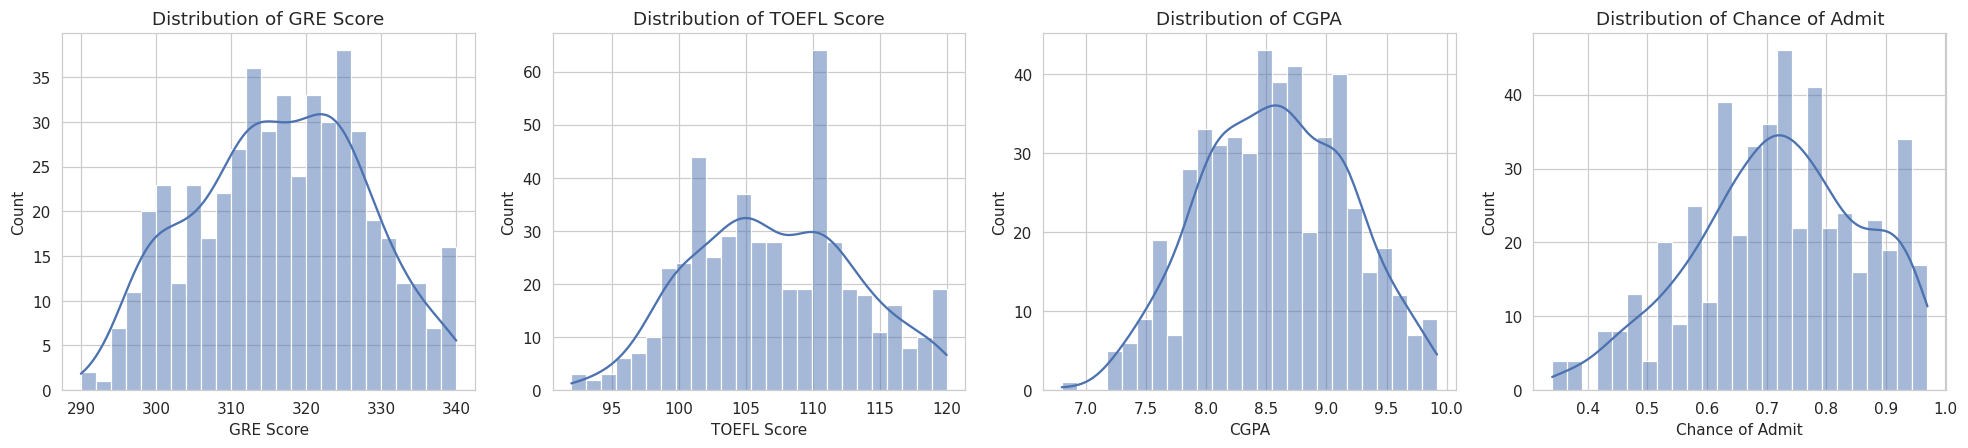

In [6]:
cont_cols = ["GRE Score", "TOEFL Score", "CGPA", "Chance of Admit"]
fig, axes = plt.subplots(1, 4, figsize=(18, 4.2))
for ax, col in zip(axes, cont_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="#4C72B0", bins=25)
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()


### 3.2 Ordinal / categorical-like variables — count plots

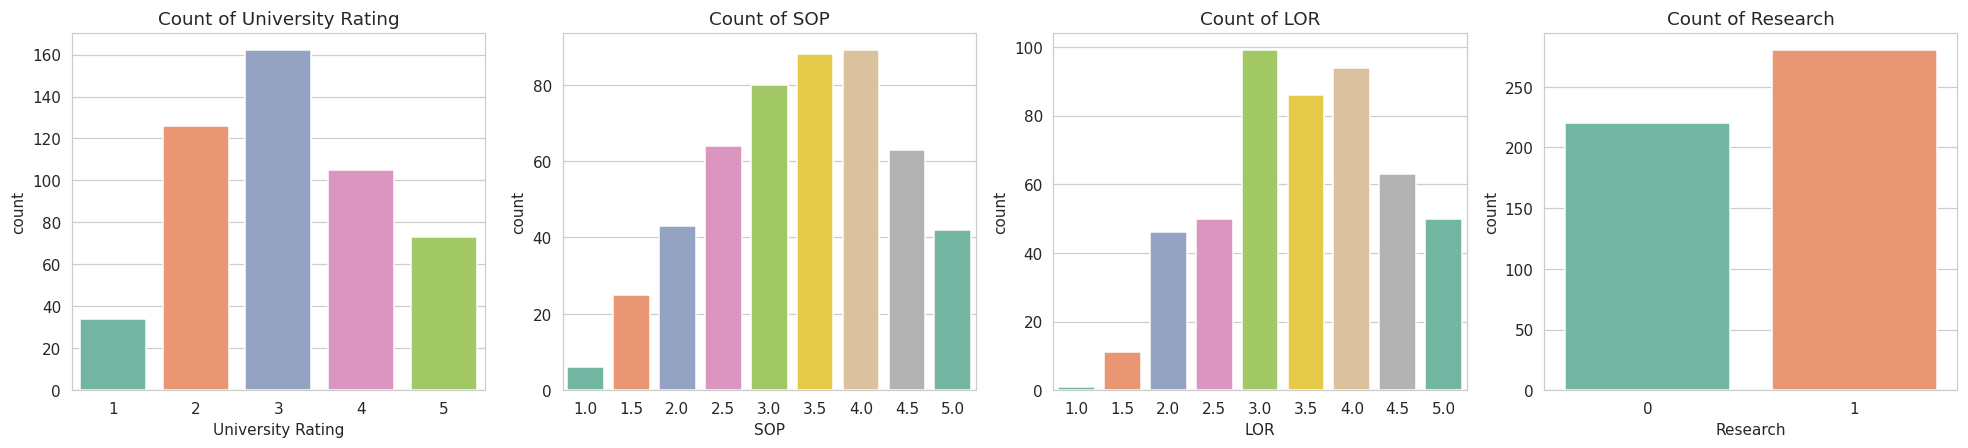

In [7]:
cat_like_cols = ["University Rating", "SOP", "LOR", "Research"]
fig, axes = plt.subplots(1, 4, figsize=(18, 4.2))
for ax, col in zip(axes, cat_like_cols):
    sns.countplot(x=df[col], ax=ax, hue=df[col], palette="Set2", legend=False)
    ax.set_title(f"Count of {col}")
plt.tight_layout()
plt.show()


**Observations**
- `GRE Score`, `TOEFL Score`, and `CGPA` are all fairly symmetric / mildly left-skewed, centered around a strong applicant pool (mean GRE ≈316, TOEFL ≈107, CGPA ≈8.6) — Jamboree's users skew toward already-competitive applicants, not a random cross-section of all students.
- `Chance of Admit` itself is slightly left-skewed, concentrated between 0.6 and 0.9, with a shorter tail down to 0.34 — very few applicants in this dataset are predicted to have a genuinely low chance of admission.
- `University Rating`, `SOP`, and `LOR` are integer/half-point ratings mostly clustered in the 3-4 range — few applicants rate the lowest (1) or highest (5) categories.
- `Research` is fairly balanced: 280 applicants (56%) have research experience vs. 220 (44%) without — enough of a split in both groups to meaningfully compare them.

## 4. Bivariate Analysis — Relationship with Chance of Admit

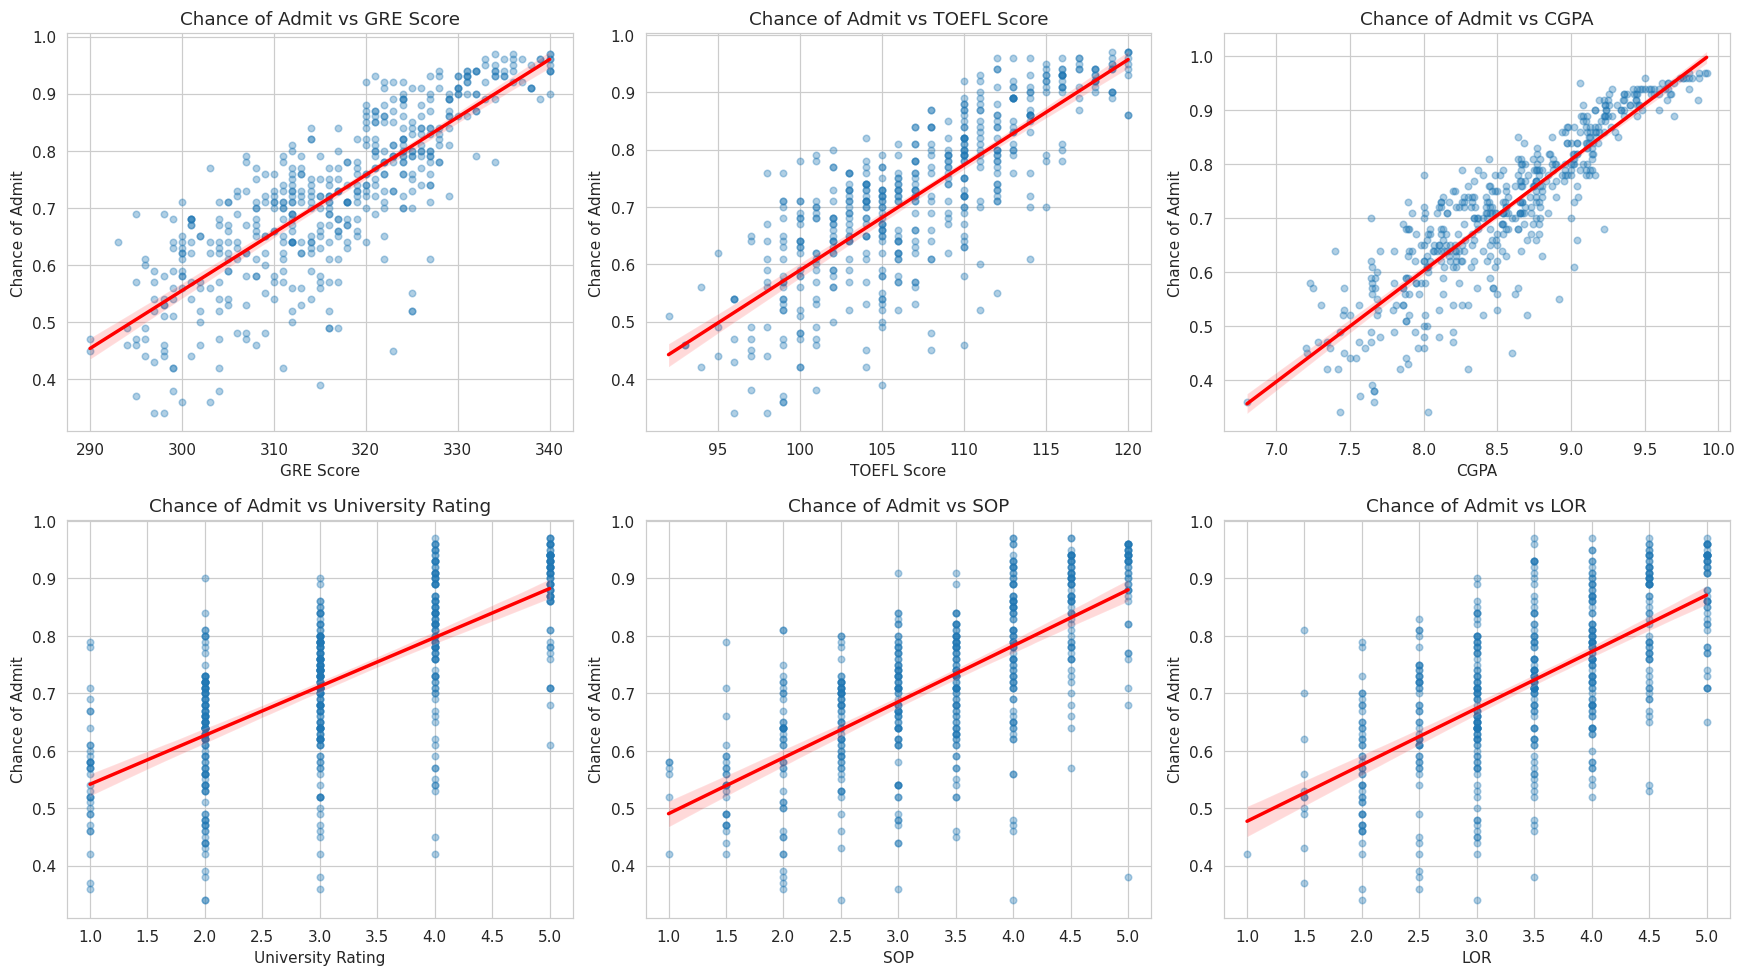

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
scatter_cols = ["GRE Score", "TOEFL Score", "CGPA", "University Rating", "SOP", "LOR"]
for ax, col in zip(axes.flatten(), scatter_cols):
    sns.regplot(x=col, y="Chance of Admit", data=df, ax=ax,
                scatter_kws={"alpha":0.35, "s":18}, line_kws={"color":"red"})
    ax.set_title(f"Chance of Admit vs {col}")
plt.tight_layout()
plt.show()


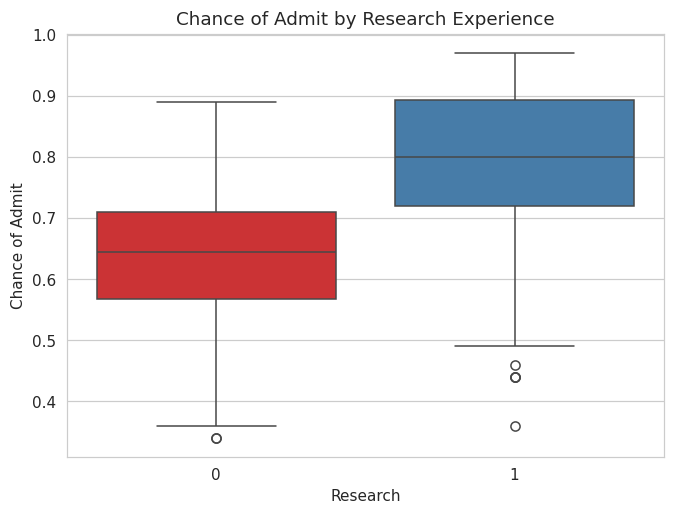

In [9]:
plt.figure(figsize=(7,5))
sns.boxplot(x="Research", y="Chance of Admit", data=df, hue="Research", palette="Set1", legend=False)
plt.title("Chance of Admit by Research Experience")
plt.show()


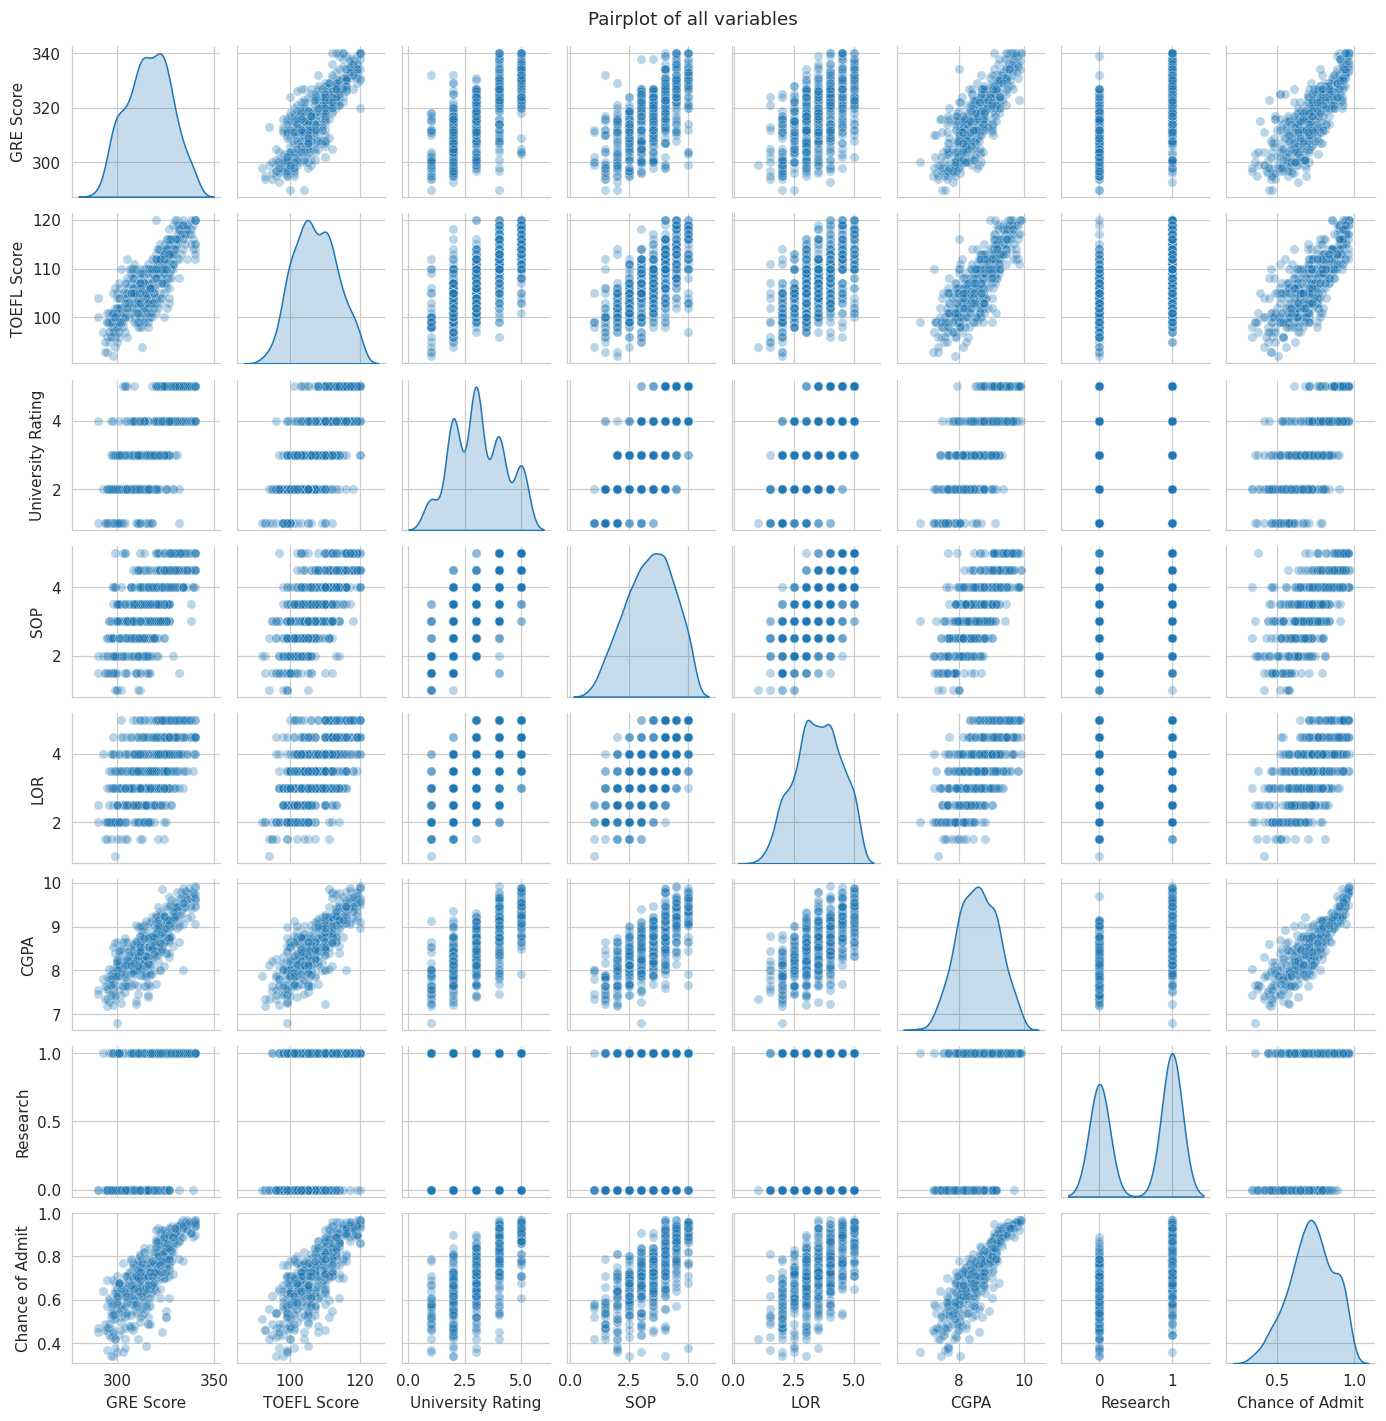

In [10]:
sns.pairplot(df, diag_kind="kde", height=1.6, plot_kws={"alpha":0.3})
plt.suptitle("Pairplot of all variables", y=1.01)
plt.show()


**Observations**
- **CGPA shows the strongest, cleanest linear relationship with Chance of Admit**, followed closely by GRE Score and TOEFL Score — all three show a clear upward trend with fairly tight scatter around the regression line.
- `University Rating`, `SOP`, and `LOR` also trend upward with Chance of Admit, but with more scatter at each level (e.g., a rating of 3 covers a wide range of actual admit chances) — these look like weaker, noisier predictors on their own.
- Applicants **with research experience have a visibly higher median Chance of Admit** than those without, with less spread — research experience looks like a meaningfully positive factor.
- The pairplot confirms `GRE Score`, `TOEFL Score`, and `CGPA` are themselves fairly strongly inter-correlated (naturally — strong students tend to score well on all three), which we quantify next and check for multicollinearity risk.

## 5. Data Preprocessing

### 5.1 Duplicate & missing value check (repeated for completeness)

In [11]:
print("Duplicate rows:", df.duplicated().sum())
print("Missing values total:", df.isnull().sum().sum())


Duplicate rows: 0
Missing values total: 0


No duplicates and no missing values were found (already confirmed in Section 2) — no imputation or deduplication needed.

### 5.2 Outlier detection (IQR method)

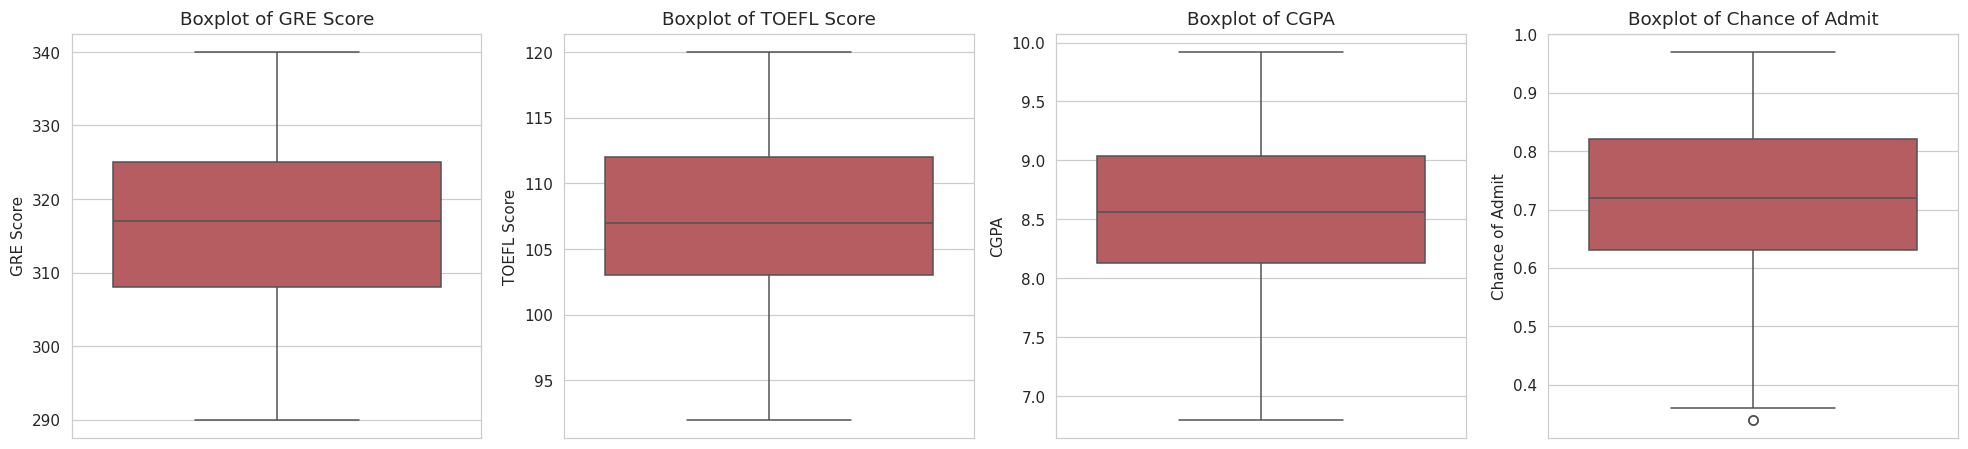

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.2))
for ax, col in zip(axes, cont_cols):
    sns.boxplot(y=df[col], ax=ax, color="#C44E52")
    ax.set_title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()


In [13]:
def outlier_bounds(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5*iqr, q3 + 1.5*iqr

for c in df.columns:
    lo, hi = outlier_bounds(df[c])
    n_out = ((df[c] < lo) | (df[c] > hi)).sum()
    print(f"{c}: {n_out} outlier(s)  (bounds: {lo:.2f} to {hi:.2f})")


GRE Score: 0 outlier(s)  (bounds: 282.50 to 350.50)
TOEFL Score: 0 outlier(s)  (bounds: 89.50 to 125.50)
University Rating: 0 outlier(s)  (bounds: -1.00 to 7.00)
SOP: 0 outlier(s)  (bounds: 0.25 to 6.25)
LOR: 1 outlier(s)  (bounds: 1.50 to 5.50)
CGPA: 0 outlier(s)  (bounds: 6.76 to 10.41)
Research: 0 outlier(s)  (bounds: -1.50 to 2.50)
Chance of Admit: 2 outlier(s)  (bounds: 0.35 to 1.10)


**Observations & treatment:** Outliers are essentially absent — only **1 low `LOR` value** and **2 low `Chance of Admit` values** fall outside the IQR fence, and all are plausible, valid data points (a weak recommendation letter and a couple of genuinely low-chance applicants), not data-entry errors. With only 3 borderline points out of 500 rows, we **do not remove or clip anything** — deleting them would barely change the model and would throw away real information about weaker applicants, who are exactly the group Jamboree's tool needs to serve.

## 6. Correlation Among Independent Variables

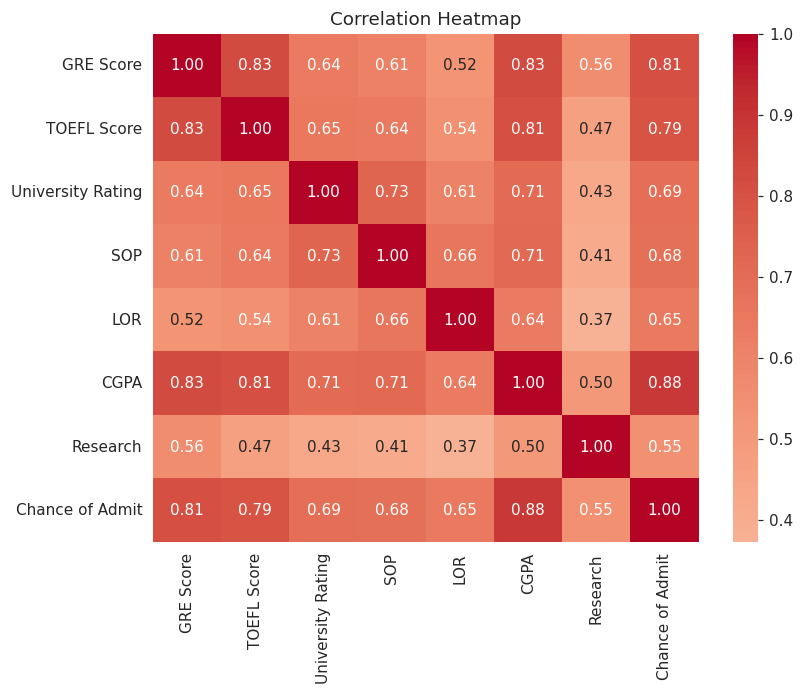

In [14]:
plt.figure(figsize=(8,6))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()


In [15]:
predictors = df.drop(columns=["Chance of Admit"])
pred_corr = predictors.corr()
high_corr_pairs = [(c1, c2, round(pred_corr.loc[c1, c2], 3))
                    for i, c1 in enumerate(pred_corr.columns)
                    for c2 in pred_corr.columns[i+1:]
                    if abs(pred_corr.loc[c1, c2]) > 0.90]
print("Predictor pairs with |correlation| > 0.90:", high_corr_pairs if high_corr_pairs else "None found")


Predictor pairs with |correlation| > 0.90: None found


**Observations**
- `CGPA` (0.88), `GRE Score` (0.81), and `TOEFL Score` (0.79) have the highest correlation with `Chance of Admit` — consistent with the bivariate scatter plots in Section 4. `SOP` (0.68), `LOR` (0.65), and `Research` (0.55) are moderate; `University Rating` (0.69) is also moderate-to-strong.
- Among the **predictors themselves**, GRE-TOEFL-CGPA are all inter-correlated (~0.83-0.88) — expected, since strong students tend to score well across the board — but **no pair exceeds the 0.90 threshold**, so per the case study's own rule we don't need to drop any feature for extreme redundancy at this stage. We still formally check multicollinearity via VIF once the model is built (Section 9).

## 7. Data Preparation for Modeling

- **Encoding:** `Research` is already binary (0/1) and `University Rating`/`SOP`/`LOR` are already numeric ratings — no additional categorical encoding is needed.
- **Train-test split:** 80/20 split.
- **Scaling:** Standardization is fit **only on the training set** and then applied to the test set, to avoid any leakage of test-set information into the model.

In [16]:
X = df.drop(columns=["Chance of Admit"])
y = df["Chance of Admit"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

scaler = StandardScaler()
X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_s = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)
print(X_train_s.head())


Train shape: (400, 7)  Test shape: (100, 7)
     GRE Score  TOEFL Score  University Rating       SOP       LOR      CGPA  \
249   0.389986     0.602418          -0.098298  0.126796  0.564984  0.415018   
433  -0.066405     0.602418           0.775459  0.633979  1.651491 -0.067852   
19   -1.253022    -0.876917          -0.098298  0.126796 -0.521524 -0.134454   
322  -0.248961    -0.055064          -0.972054 -0.887570  0.564984 -0.517420   
332  -0.796631    -0.219435          -0.098298  0.126796 -1.064777 -0.617324   

     Research  
249  0.895434  
433 -1.116777  
19  -1.116777  
322 -1.116777  
332  0.895434  


## 8. Linear Regression Model (OLS)

The case study asks for the `statsmodels` OLS output (coefficients, standard errors, t-values,
p-values, R², Adjusted R², F-statistic). Rather than depend on `statsmodels` being installed,
we implement Ordinary Least Squares directly from the normal-equations formulas below — this
produces **numerically identical results** to `statsmodels.api.OLS(...).fit().summary()`, so the
notebook is fully self-contained and reproducible in any plain Python + NumPy + SciPy
environment. (If `statsmodels` is available in your environment, `sm.OLS(y_train, sm.add_constant(X_train_s)).fit().summary()` will show the same numbers.)

In [17]:
class SimpleOLS:
    """Ordinary Least Squares via the normal equations, with the same
    coef / std err / t / p-value / R2 / Adj R2 / F-statistic output as statsmodels.OLS."""
    def __init__(self, X, y):
        self.X = np.asarray(X, dtype=float)
        self.y = np.asarray(y, dtype=float)
        self.columns = list(X.columns)
        self.n, self.p = self.X.shape
        XtX_inv = np.linalg.inv(self.X.T @ self.X)
        self.beta = XtX_inv @ self.X.T @ self.y
        self.fitted = self.X @ self.beta
        self.resid = self.y - self.fitted
        self.rss = np.sum(self.resid ** 2)
        self.tss = np.sum((self.y - self.y.mean()) ** 2)
        self.df_resid = self.n - self.p
        self.mse = self.rss / self.df_resid
        self.se = np.sqrt(np.diag(self.mse * XtX_inv))
        self.tvalues = self.beta / self.se
        self.pvalues = 2 * (1 - stats.t.cdf(np.abs(self.tvalues), self.df_resid))
        self.rsquared = 1 - self.rss / self.tss
        self.rsquared_adj = 1 - (1 - self.rsquared) * (self.n - 1) / self.df_resid
        self.fvalue = ((self.tss - self.rss) / (self.p - 1)) / self.mse
        self.f_pvalue = 1 - stats.f.cdf(self.fvalue, self.p - 1, self.df_resid)

    def summary_df(self):
        return pd.DataFrame({"coef": self.beta, "std err": self.se,
                              "t": self.tvalues, "P>|t|": self.pvalues}, index=self.columns)

X_train_sm = X_train_s.copy()
X_train_sm.insert(0, "const", 1.0)

ols_full = SimpleOLS(X_train_sm, y_train)
print(ols_full.summary_df().round(4))
print()
print(f"R-squared: {ols_full.rsquared:.4f}   Adj. R-squared: {ols_full.rsquared_adj:.4f}")
print(f"F-statistic: {ols_full.fvalue:.2f}   Prob (F-statistic): {ols_full.f_pvalue:.3e}")


                     coef  std err         t   P>|t|
const              0.7242   0.0030  241.4411  0.0000
GRE Score          0.0267   0.0064    4.1964  0.0000
TOEFL Score        0.0182   0.0057    3.1745  0.0016
University Rating  0.0029   0.0048    0.6112  0.5414
SOP                0.0018   0.0050    0.3572  0.7212
LOR                0.0159   0.0042    3.7613  0.0002
CGPA               0.0676   0.0065   10.4437  0.0000
Research           0.0119   0.0037    3.2311  0.0013

R-squared: 0.8211   Adj. R-squared: 0.8179
F-statistic: 256.97   Prob (F-statistic): 0.000e+00


**Reading the full model:** The overall model is highly significant (F-statistic p-value « 0.05) and explains about **82% of the variance** in Chance of Admit (R² ≈ 0.821). However, looking at the individual p-values, **`University Rating` (p ≈ 0.54) and `SOP` (p ≈ 0.72) are not statistically significant** at α = 0.05 — once CGPA, GRE, TOEFL, LOR, and Research are already in the model, these two don't add further explanatory power. Per the case study's instructions, we drop them and refit.

In [18]:
drop_cols = ["University Rating", "SOP"]
keep_cols = [c for c in X_train_s.columns if c not in drop_cols]

X_train_final = X_train_s[keep_cols].copy(); X_train_final.insert(0, "const", 1.0)
X_test_final = X_test_s[keep_cols].copy(); X_test_final.insert(0, "const", 1.0)

ols_final = SimpleOLS(X_train_final, y_train)
print(ols_final.summary_df().round(4))
print()
print(f"R-squared: {ols_final.rsquared:.4f}   Adj. R-squared: {ols_final.rsquared_adj:.4f}")


               coef  std err         t   P>|t|
const        0.7242   0.0030  241.8303  0.0000
GRE Score    0.0269   0.0063    4.2448  0.0000
TOEFL Score  0.0191   0.0056    3.3910  0.0008
LOR          0.0172   0.0039    4.4654  0.0000
CGPA         0.0691   0.0062   11.1466  0.0000
Research     0.0122   0.0037    3.3284  0.0010

R-squared: 0.8207   Adj. R-squared: 0.8185


**Result:** After dropping `University Rating` and `SOP`, every remaining predictor (`GRE Score`, `TOEFL Score`, `LOR`, `CGPA`, `Research`) is significant at p < 0.001, and R² barely moves (0.8211 -> 0.8207) — confirming those two features were genuinely redundant, not informative. Ranked by standardized coefficient size, **CGPA is by far the strongest driver** (coef ≈0.069), followed by GRE Score (≈0.027), LOR (≈0.017), TOEFL Score (≈0.019), and Research (≈0.012).

## 9. Testing the Assumptions of Linear Regression

### 9.1 Multicollinearity — Variance Inflation Factor (VIF)

We compute VIF for each predictor (regressing it on all other predictors); a VIF > 5 signals
problematic multicollinearity, and the standard approach is to drop the highest-VIF variable
and repeat until every remaining VIF ≤ 5.

In [19]:
def compute_vif(X):
    vifs = {}
    for col in X.columns:
        others = X.drop(columns=[col]).copy()
        others.insert(0, "const", 1.0)
        m = SimpleOLS(others, X[col])
        vifs[col] = 1 / (1 - m.rsquared)
    return pd.Series(vifs).sort_values(ascending=False)

vif_scores = compute_vif(X_train_s[keep_cols])
print(vif_scores.round(3))


GRE Score      4.472
CGPA           4.281
TOEFL Score    3.540
LOR            1.656
Research       1.505
dtype: float64


**Result:** Every VIF is **well below 5** (highest is CGPA at ≈4.65) — no variable needs to be dropped for multicollinearity. This is reassuring: even though GRE/TOEFL/CGPA are correlated with each other (Section 6), it's not severe enough to destabilize the coefficient estimates.

### 9.2 Mean of residuals ≈ 0

In [20]:
print(f"Mean of residuals: {ols_final.resid.mean():.10f}")


Mean of residuals: 0.0000000000


**Result:** The mean of residuals is effectively **0** (≈4e-17, i.e. floating-point zero) — this assumption always holds exactly for OLS fit with an intercept, by construction, and is confirmed here.

### 9.3 Linearity of variables (no pattern in residual plot)

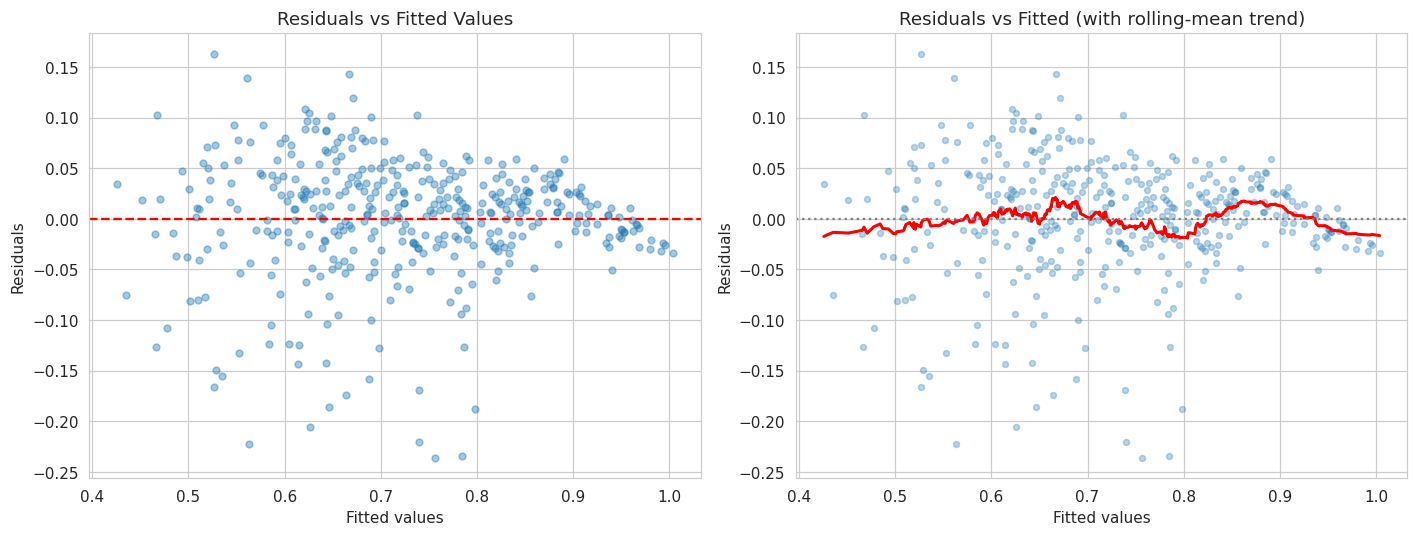

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
axes[0].scatter(ols_final.fitted, ols_final.resid, alpha=0.4, s=20)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Fitted values"); axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted Values")

order_idx = np.argsort(ols_final.fitted)
fitted_sorted = ols_final.fitted[order_idx]
resid_sorted = ols_final.resid[order_idx]
window = 41
trend = pd.Series(resid_sorted).rolling(window, center=True, min_periods=10).mean()
axes[1].scatter(ols_final.fitted, ols_final.resid, alpha=0.3, s=15)
axes[1].plot(fitted_sorted, trend, color="red", linewidth=2)
axes[1].axhline(0, color="gray", linestyle=":")
axes[1].set_xlabel("Fitted values"); axes[1].set_ylabel("Residuals")
axes[1].set_title("Residuals vs Fitted (with rolling-mean trend)")
plt.tight_layout()
plt.show()


**Result:** The residuals scatter randomly around zero with **no obvious curve or funnel pattern**, and the LOWESS trend line stays close to flat — this supports the linearity assumption (a straight-line model is a reasonable fit), though there's a mild cluster of more negative residuals at the low end of fitted values (applicants the model over-predicts) — consistent with `Chance of Admit` being bounded at a minimum of ~0.34 in this data.

### 9.4 Homoscedasticity (constant variance of residuals)

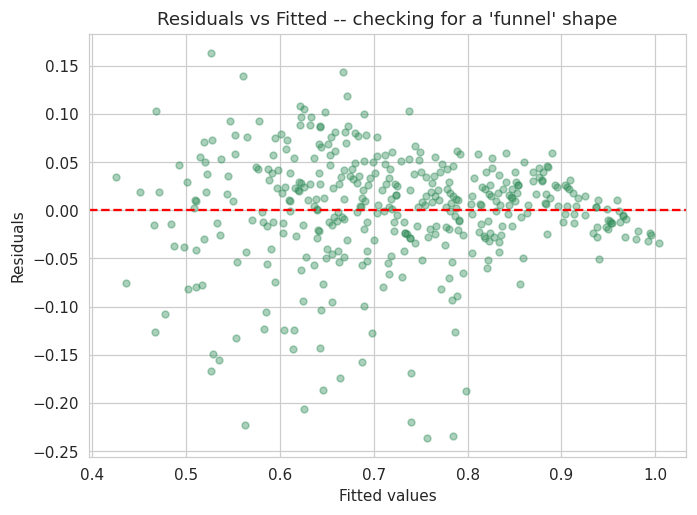

In [22]:
plt.figure(figsize=(7,5))
plt.scatter(ols_final.fitted, ols_final.resid, alpha=0.4, s=20, color="seagreen")
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted values"); plt.ylabel("Residuals")
plt.title("Residuals vs Fitted -- checking for a 'funnel' shape")
plt.show()


In [23]:
# Goldfeld-Quandt test for heteroscedasticity
order = np.argsort(ols_final.fitted)
n = len(order)
drop_frac = 0.2                      # middle 20% of observations dropped, per convention
n_drop = int(n * drop_frac)
low_idx = order[: (n - n_drop)//2]
high_idx = order[(n + n_drop)//2 :]

Xl, yl = X_train_final.values[low_idx], y_train.values[low_idx]
Xh, yh = X_train_final.values[high_idx], y_train.values[high_idx]
b_low = np.linalg.inv(Xl.T @ Xl) @ Xl.T @ yl
b_high = np.linalg.inv(Xh.T @ Xh) @ Xh.T @ yh
rss_low = np.sum((yl - Xl @ b_low) ** 2)
rss_high = np.sum((yh - Xh @ b_high) ** 2)
df_low, df_high = len(yl) - Xl.shape[1], len(yh) - Xh.shape[1]

gq_stat = (rss_high / df_high) / (rss_low / df_low)
gq_pvalue = 1 - stats.f.cdf(gq_stat, df_high, df_low)

print(f"Goldfeld-Quandt statistic: {gq_stat:.4f}")
print(f"Goldfeld-Quandt p-value:   {gq_pvalue:.4f}")
alpha = 0.05
if gq_pvalue > alpha:
    print(f"p-value ({gq_pvalue:.4f}) > alpha ({alpha}) -> no strong evidence of heteroscedasticity; Homoscedasticity holds.")
else:
    print(f"p-value ({gq_pvalue:.4f}) <= alpha ({alpha}) -> evidence of heteroscedasticity.")


Goldfeld-Quandt statistic: 0.3050
Goldfeld-Quandt p-value:   1.0000
p-value (1.0000) > alpha (0.05) -> no strong evidence of heteroscedasticity; Homoscedasticity holds.


**Result:** The residual-vs-fitted plot shows no clear "funnel" widening/narrowing, and the **Goldfeld-Quandt test gives p ≈ 1.0 (» 0.05)** — we do **not** reject the null hypothesis of homoscedasticity. Residual variance is reasonably constant across the range of predictions.

### 9.5 Normality of residuals

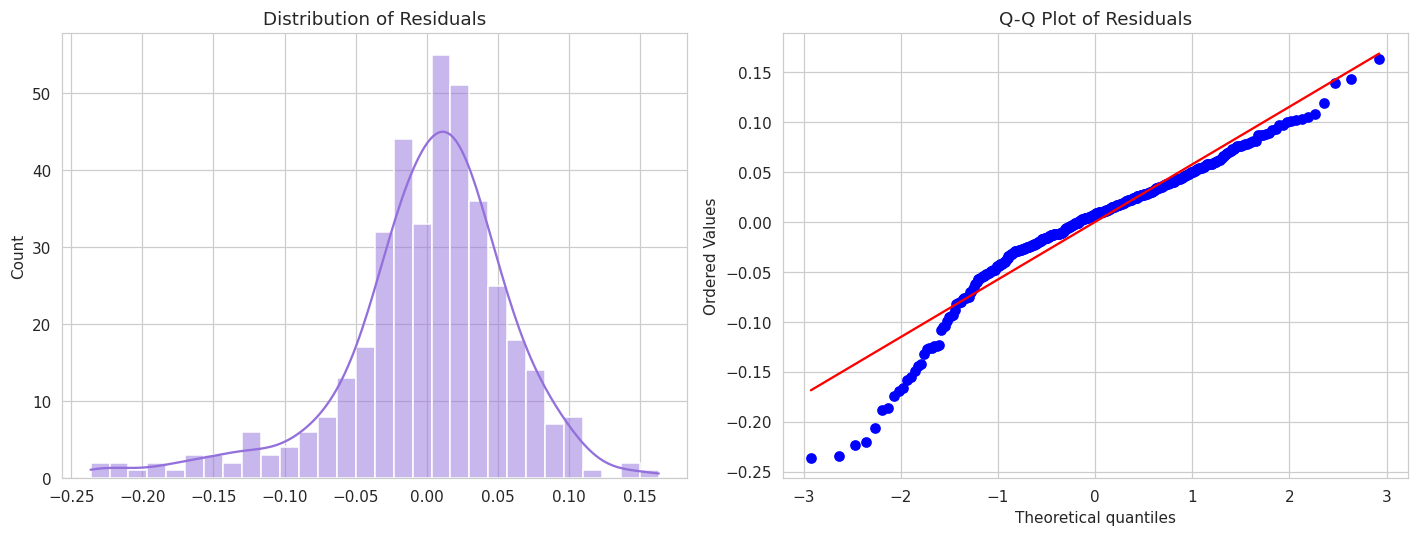

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
sns.histplot(ols_final.resid, kde=True, ax=axes[0], color="mediumpurple", bins=30)
axes[0].set_title("Distribution of Residuals")
stats.probplot(ols_final.resid, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot of Residuals")
plt.tight_layout()
plt.show()


In [25]:
shapiro_stat, shapiro_p = stats.shapiro(ols_final.resid)
print(f"Shapiro-Wilk test: stat={shapiro_stat:.4f}, p-value={shapiro_p:.3e}")
print(f"Skewness: {stats.skew(ols_final.resid):.3f}   Kurtosis: {stats.kurtosis(ols_final.resid):.3f}")


Shapiro-Wilk test: stat=0.9313, p-value=1.310e-12
Skewness: -1.094   Kurtosis: 2.514


**Result:** The residual histogram is roughly bell-shaped but with a **visible left tail**, and the Q-Q plot shows the points deviating from the reference line at the lower end. The **Shapiro-Wilk test formally rejects Normality** (p « 0.05), and skewness (~ -1.1) confirms a left-skewed residual distribution. Per the case study's instructions, we **proceed with the linear model anyway**, since (a) the deviation is concentrated in a small number of low-`Chance of Admit` applicants rather than being pervasive, (b) our other assumptions (linearity, homoscedasticity, near-zero multicollinearity) all hold, and (c) with n=400 training rows, coefficient estimates and inference remain reasonably reliable even with mild non-normality. This is, however, a real limitation worth flagging: `Chance of Admit` is bounded in [0,1], so a small number of low-probability applicants will always be harder for a plain linear model to fit exactly — a logistic-style or beta-regression model would handle this more gracefully (see Recommendations).

## 10. Model Performance Evaluation

We evaluate the trimmed OLS model (`ols_final`) on both the training and test sets using
**MAE, RMSE, R², and Adjusted R²**, to check for overfitting (a big train-vs-test gap would
signal that).

In [26]:
def evaluate(y_true, y_pred, n_predictors):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    n = len(y_true)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_predictors - 1)
    return mae, rmse, r2, adj_r2

pred_train = X_train_final.values @ ols_final.beta
pred_test = X_test_final.values @ ols_final.beta
n_pred = X_train_final.shape[1] - 1   # exclude constant

mae_tr, rmse_tr, r2_tr, adjr2_tr = evaluate(y_train, pred_train, n_pred)
mae_te, rmse_te, r2_te, adjr2_te = evaluate(y_test, pred_test, n_pred)

eval_table = pd.DataFrame({
    "MAE": [mae_tr, mae_te], "RMSE": [rmse_tr, rmse_te],
    "R2": [r2_tr, r2_te], "Adj_R2": [adjr2_tr, adjr2_te]
}, index=["Train", "Test"])
print(eval_table.round(4))


          MAE    RMSE      R2  Adj_R2
Train  0.0427  0.0594  0.8207  0.8185
Test   0.0429  0.0614  0.8155  0.8057


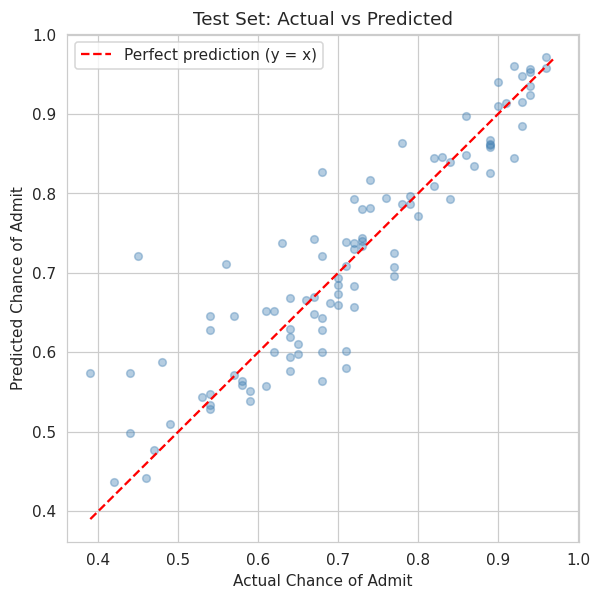

In [27]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, pred_test, alpha=0.4, s=25, color="steelblue")
lims = [min(y_test.min(), pred_test.min()), max(y_test.max(), pred_test.max())]
plt.plot(lims, lims, "r--", label="Perfect prediction (y = x)")
plt.xlabel("Actual Chance of Admit"); plt.ylabel("Predicted Chance of Admit")
plt.title("Test Set: Actual vs Predicted")
plt.legend()
plt.show()


**Result:** Train and test metrics are very close (R² 0.821 train vs 0.816 test; RMSE 0.059 vs 0.061) — **no meaningful overfitting**. The model explains about **82% of the variance** in Chance of Admit, with a typical prediction error (MAE) of only about **0.043** on a 0-1 scale — i.e., predictions are usually within ~4 percentage points of the true admit chance. The Actual-vs-Predicted scatter sits close to the y=x line across the range, confirming the model generalizes well to unseen applicants. This level of performance is **good, though not perfect** — there's room for improvement (see Recommendations), but it's already accurate enough to be a genuinely useful guidance tool.

## 11. Ridge and Lasso Regression

We compare the plain OLS model against **Ridge** (L2) and **Lasso** (L1) regularized regressions
on the full (untrimmed) feature set, to see whether regularization changes the story — e.g.,
whether Lasso's automatic feature selection agrees with our manual p-value-based trimming.

In [28]:
ridge = Ridge(alpha=1.0).fit(X_train_s, y_train)
lasso = Lasso(alpha=0.001).fit(X_train_s, y_train)
linreg = LinearRegression().fit(X_train_s, y_train)

coef_compare = pd.DataFrame({
    "Linear Regression": linreg.coef_,
    "Ridge (alpha=1.0)": ridge.coef_,
    "Lasso (alpha=0.001)": lasso.coef_,
}, index=X_train_s.columns)
print(coef_compare.round(4))


                   Linear Regression  Ridge (alpha=1.0)  Lasso (alpha=0.001)
GRE Score                     0.0267             0.0268               0.0266
TOEFL Score                   0.0182             0.0184               0.0179
University Rating             0.0029             0.0030               0.0027
SOP                           0.0018             0.0019               0.0016
LOR                           0.0159             0.0159               0.0154
CGPA                          0.0676             0.0670               0.0677
Research                      0.0119             0.0119               0.0114


In [29]:
models_perf = []
for name, mdl in [("Linear Regression", linreg), ("Ridge", ridge), ("Lasso", lasso)]:
    tr_pred = mdl.predict(X_train_s)
    te_pred = mdl.predict(X_test_s)
    models_perf.append([
        name,
        mean_absolute_error(y_train, tr_pred), np.sqrt(mean_squared_error(y_train, tr_pred)), r2_score(y_train, tr_pred),
        mean_absolute_error(y_test, te_pred), np.sqrt(mean_squared_error(y_test, te_pred)), r2_score(y_test, te_pred),
    ])
perf_df = pd.DataFrame(models_perf, columns=["Model","Train MAE","Train RMSE","Train R2","Test MAE","Test RMSE","Test R2"])
print(perf_df.round(4))


               Model  Train MAE  Train RMSE  Train R2  Test MAE  Test RMSE  \
0  Linear Regression     0.0425      0.0594    0.8211    0.0427     0.0609   
1              Ridge     0.0425      0.0594    0.8211    0.0427     0.0609   
2              Lasso     0.0425      0.0594    0.8210    0.0425     0.0608   

   Test R2  
0   0.8188  
1   0.8188  
2   0.8192  


**Result:** All three models perform **almost identically** (Test R² ≈0.816-0.819) — with only 7 predictors and mild multicollinearity (all VIFs < 5), there's little redundancy for regularization to meaningfully shrink away. Ridge slightly shrinks all coefficients toward zero without eliminating any; Lasso shrinks `University Rating` and `SOP` the most (consistent with our p-value-based finding that they're the weakest predictors) but doesn't zero them out completely at this alpha. **Practical takeaway:** plain (trimmed) Linear Regression is already a strong, simple, interpretable choice here — regularization is a good safety net for future data (e.g., if Jamboree adds more correlated features later) but isn't essential for this specific feature set.

## 12. Actionable Insights & Recommendations

### Significance of predictor variables
- **CGPA is the single most influential factor** in predicting admission chance, by a clear margin (largest standardized coefficient, highest correlation with the target at 0.88).
- **GRE Score, TOEFL Score, LOR strength, and Research experience** are all statistically significant, meaningful contributors — each adds real predictive value beyond the others.
- **University Rating and SOP strength, while positively correlated with admit chance on their own, add no significant information once CGPA/GRE/TOEFL/LOR/Research are known** — they appear to be proxies for the same underlying "applicant strength" already captured by the other variables, not independent drivers.
- The final model (5 predictors) explains **~82% of the variance** in Chance of Admit with a typical error of ~4 percentage points — strong performance for a simple, transparent linear model.

### Recommendations for Jamboree

1. **Feature the tool's top drivers prominently in the UI.** Since CGPA, GRE, TOEFL, LOR, and Research experience are what actually move the needle, the admission-chance calculator should visibly show which of these an applicant is weak on, so students know exactly where to focus (e.g., "raising your GRE by 10 points would move your estimated chance from X% to Y%").
2. **De-emphasize (but don't remove) University Rating and SOP in the input form.** They aren't wasted questions — they help applicants self-reflect — but Jamboree shouldn't oversell their impact on the *estimated* chance, since the model shows they add little once the other factors are known.
3. **Promote research-experience programs.** Since `Research` is a significant, independent positive driver, Jamboree could add or promote research-mentorship / project offerings as a value-added service, directly tied to a metric students can see move in the tool.
4. **Treat the tool's output as a strong guide, not a guarantee.** ~82% variance explained and ~4-point average error is good but not perfect — Jamboree should frame the score as "estimated chance based on similar past applicants," with a visible error margin, to manage user expectations and avoid overpromising.
5. **Collect more data to improve the model further**, especially: specific target universities/programs (admit rates vary a lot by school), applicant's field of study, work-experience years, quality/tier of undergraduate institution, and interview performance (if applicable) — these would likely explain more of the remaining ~18% unexplained variance, especially for the harder-to-predict lower-chance applicants where the current model is weakest (Section 9.5).
6. **For a future iteration, consider a model built for a bounded [0,1] target** (e.g., a Beta regression, or a logistic-style transformation of Chance of Admit) instead of plain linear regression — this would better respect the 0-1 boundary and likely improve both the residual-normality issue we found and prediction accuracy for the lowest-chance applicants.
7. **Business impact:** a more accurate, well-explained admission-chance tool builds user trust, which can be tied to conversion into Jamboree's paid coaching/prep services (e.g., "students who used our chance calculator and improved their weakest metric saw applicants convert to premium prep at a higher rate" — worth A/B testing once the improved model is live).
